# Compare pitch decay with fitted damping and without damping

This notebook creates two figures for the same pitch decay test:

1. Best/fitted pitch damping values.
2. Simulation without additional pitch damping.

Both figures show the experiment, simulation, matched extrema and the simulation initial amplitude. The title includes the NRMSE for both plots.

In [1]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import find_peaks

import OrcFxAPI

In [2]:
# ============================================================
# 2. Paths and settings
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

# Requested experiment: fixed with deck, pitch, Decay1
exp_path = data_root / "02" / "003" / "34224_03CB_02_003_002_01_Decay1.h5m"
model_path = orca_root / "Harlequin_fixed_120s_aerocorrected.dat"

output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess")
plots_dir = output_dir / "plots_pitch_fixedwith_damped_vs_undamped"
tables_dir = output_dir / "tables"
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

output_excel_path = tables_dir / "pitch_fixedwith_damped_vs_undamped_summary.xlsx"

# Case definition
construction = "fixedwith"
construction_label = "Fixed with deck"
dof = "pitch"

# Fitted viscous pitch damping values shown in the example figure
fitted_linear_damping = 303.333
fitted_quadratic_damping = 50.000

# For pitch/roll runs, keep the selected heave damping active.
# Set this to False if you want the undamped case to have all viscous damping disabled.
KEEP_HEAVE_DAMPING_ACTIVE = True
selected_heave_damping = {
    "fixedwith": {"linear": 4.437500, "quadratic": 2.937500},
    "fixedwithout": {"linear": 0.812500, "quadratic": 1.375000},
    "spring": {"linear": 4.562500, "quadratic": 2.750000},
}

# Added mass values for fixed with deck
added_mass_values = {
    "HydrodynamicMassZ": 18.0,
    "HydrodynamicInertiaX": 0.0,
    "HydrodynamicInertiaY": 0.0,
}

# Plot settings
TITLE_SIZE = 15
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 10
FIGSIZE = (15, 6.5)
DPI = 250

# OrcaFlex object names
vesselname = "floaters"
vesseltypename = "floatertype"

# Signal/scoring settings, aligned with the calibration notebooks
prominence = 0.2
min_initial_amp = 3.0


In [3]:
# ============================================================
# 3. Experiment helper functions
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z


def find_first_zero_crossing(t, z):
    z = np.asarray(z)
    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]
    raise ValueError("No zero crossing found.")


def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)
    if np.sum(mask) == 0:
        raise ValueError("No data found in search window for initial amplitude.")

    t_win = t[mask]
    z_win = z[mask]
    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]


def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"


def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Unknown extremum_type: {extremum_type}")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(
            f"Not enough {extremum_type}s found after reference time {t_reference:.3f} s."
        )

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }


def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)
    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp:
        raise ValueError(
            f"Initial amplitude too small: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence,
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]
    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }

In [4]:
# ============================================================
# 4. Extrema and NRMSE helper functions
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)
    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }


def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])


def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)
    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = np.maximum(np.abs(z_ref), 1e-6)
    return float(np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2)))


def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(
        exp_extrema["z_peaks"], sim_extrema["z_peaks"]
    )
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(
        exp_extrema["z_troughs"], sim_extrema["z_troughs"]
    )

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)
    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = float(np.mean(vals)) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)

In [5]:
# ============================================================
# 5. OrcaFlex helper functions
# ============================================================
def safe_setattr(obj, attr_name: str, value: float):
    try:
        setattr(obj, attr_name, float(value))
    except Exception as exc:
        print(f"Warning: could not set {attr_name} = {value}: {exc}")


def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """Set only the selected DOF to the initial amplitude; all other initial DOFs are zero."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Unknown DOF: {dof}")


def reset_viscous_damping(vesseltype):
    """Set all additional viscous damping coefficients used in this workflow to zero."""
    for attr in [
        "OtherDampingLinearCoeffz", "OtherDampingQuadraticCoeffz",
        "OtherDampingLinearCoeffRx", "OtherDampingQuadraticCoeffRx",
        "OtherDampingLinearCoeffRy", "OtherDampingQuadraticCoeffRy",
    ]:
        safe_setattr(vesseltype, attr, 0.0)


def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """Set linear and quadratic viscous damping for one DOF."""
    dof = dof.lower()

    if dof == "pitch":
        vesseltype.OtherDampingLinearCoeffRy = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRy = float(quad_coeff)
    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRx = float(quad_coeff)
    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffz = float(quad_coeff)
    else:
        raise ValueError(f"Unknown DOF: {dof}")


def set_aero_added_mass(model):
    """Set hydrodynamic added mass/inertia on the OrcaFlex object 'aeroaddedmass'."""
    aeroaddedmass = model["aeroaddedmass"]
    for attr, value in added_mass_values.items():
        safe_setattr(aeroaddedmass, attr, value)


def run_orcaflex_decay(lin_coeff: float, quad_coeff: float):
    """Run one OrcaFlex pitch decay simulation and return the simulated time history."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model)
    reset_viscous_damping(vesseltype)

    if KEEP_HEAVE_DAMPING_ACTIVE:
        heave = selected_heave_damping[construction]
        set_damping(vesseltype, "heave", heave["linear"], heave["quadratic"])

    set_initial_amplitude(vessel, dof, exp_info["a_A2"])
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)

    return t - t[0], z

In [6]:
# ============================================================
# 6. Run the two simulations
# ============================================================
exp_info = prepare_experiment(exp_path, dof)

cases = [
    {
        "case_id": "fitted_damping",
        "title_label": "Best simulation",
        "legend_label": "Best simulation",
        "linear_damping": fitted_linear_damping,
        "quadratic_damping": fitted_quadratic_damping,
        "filename": "pitch_fixedwith_best_simulation.png",
    },
    {
        "case_id": "without_damping",
        "title_label": "Simulation without damping",
        "legend_label": "Simulation without damping",
        "linear_damping": 0.0,
        "quadratic_damping": 0.0,
        "filename": "pitch_fixedwith_without_damping.png",
    },
]

exp_extrema = get_peaks_and_troughs(
    exp_info["t_decay"], exp_info["z_decay"], prominence=prominence
)

results = []
for case in cases:
    print("=" * 90)
    print(f"Running: {case['title_label']}")
    print(f"Linear = {case['linear_damping']:.3f}, Quadratic = {case['quadratic_damping']:.3f}")

    t_sim, z_sim = run_orcaflex_decay(
        lin_coeff=case["linear_damping"],
        quad_coeff=case["quadratic_damping"],
    )

    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)
    nrmse_total, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
        exp_extrema, sim_extrema
    )

    result = {
        **case,
        "t_sim": t_sim,
        "z_sim": z_sim,
        "sim_extrema": sim_extrema,
        "nrmse_total": nrmse_total,
        "nrmse_peaks": nrmse_peaks,
        "nrmse_troughs": nrmse_troughs,
        "n_matched_peaks": n_peaks,
        "n_matched_troughs": n_troughs,
    }
    results.append(result)

    print(f"NRMSE = {nrmse_total:.6f}")

Running: Best simulation
Linear = 303.333, Quadratic = 50.000
NRMSE = 0.084354
Running: Simulation without damping
Linear = 0.000, Quadratic = 0.000
NRMSE = 2.972913


In [11]:
# ============================================================
# 7. Plot function
# ============================================================
def plot_case(result, save_dir: Path):
    exp_name = exp_path.stem
    t_exp_full_rel = exp_info["t_full_rel"]
    z_exp_full = exp_info["z_full"]
    t_decay = exp_info["t_decay"]
    z_decay = exp_info["z_decay"]

    sim_ext = result["sim_extrema"]

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.plot(
        t_exp_full_rel,
        z_exp_full,
        label="Experiment",
        linewidth=2.2,
        color="tab:blue",
        zorder=2,
    )

    ax.plot(
        result["t_sim"],
        result["z_sim"],
        label=result["legend_label"],
        linewidth=2.0,
        color="orange",
        zorder=3,
    )

    # Extrema markers, based on the aligned decay part.
    ax.scatter(
        exp_extrema["t_peaks"], exp_extrema["z_peaks"],
        label="Extrema (experiment)",
        color="tab:blue",
        s=35,
        zorder=4,
    )
    ax.scatter(
        exp_extrema["t_troughs"], exp_extrema["z_troughs"],
        color="tab:blue",
        s=35,
        zorder=4,
    )

    ax.scatter(
        sim_ext["t_peaks"], sim_ext["z_peaks"],
        label="Extrema (simulation)",
        color="orange",
        s=35,
        zorder=5,
    )
    ax.scatter(
        sim_ext["t_troughs"], sim_ext["z_troughs"],
        color="orange",
        s=35,
        zorder=5,
    )

    ax.scatter(
        result["t_sim"][0], result["z_sim"][0],
        marker="x",
        color="orange",
        s=170,
        linewidths=3.0,
        label="Initial amplitude (simulation)",
        zorder=6,
    )

    ax.set_title(
        f"Type: {construction} - DOF: {dof} - Exp: {exp_name}\n"
        f"Linear={result['linear_damping']:.3f}, Quadratic={result['quadratic_damping']:.3f}\n"
        f"NRMSE={result['nrmse_total']:.5f}",
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    ax.set_ylabel("Pitch [degrees]", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    x_min = -15
    x_max = 125
    ax.set_xlim(x_min, x_max)

    ax.grid(True, alpha=0.65)
    ax.legend(fontsize=LEGEND_SIZE, loc="upper right")
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / result["filename"]
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    return out_path

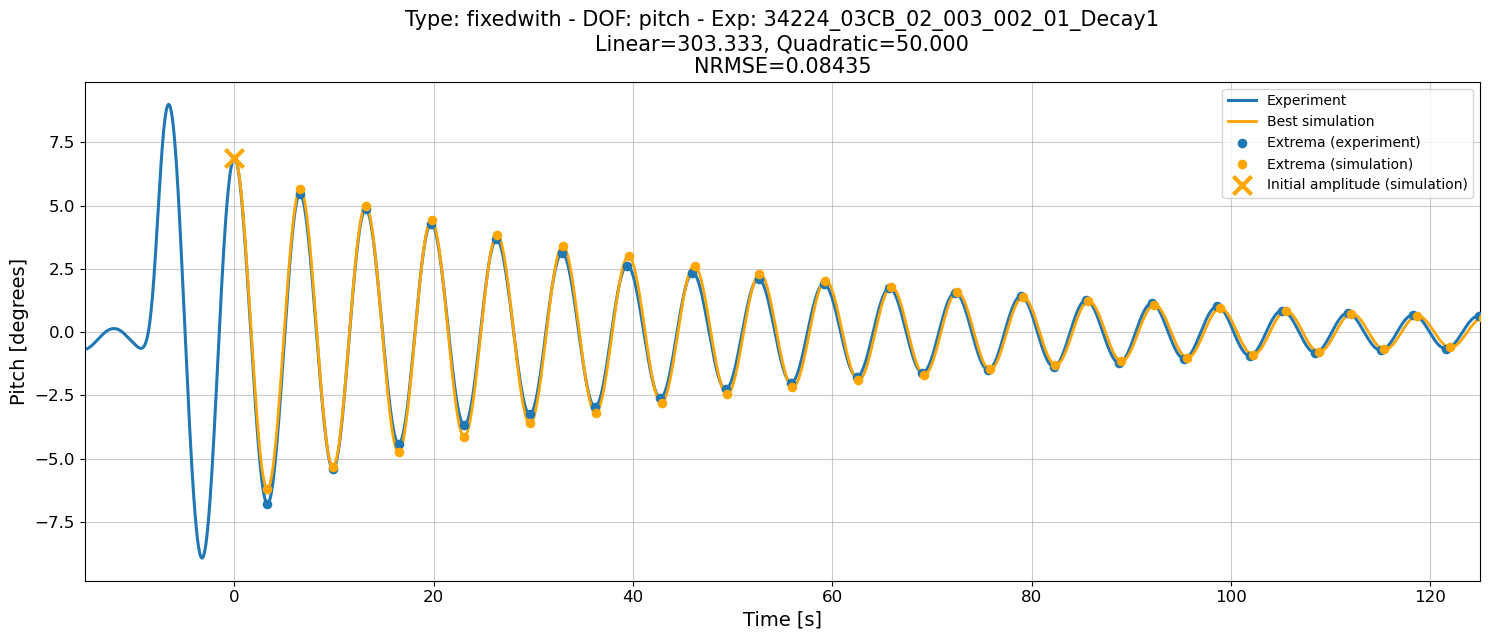

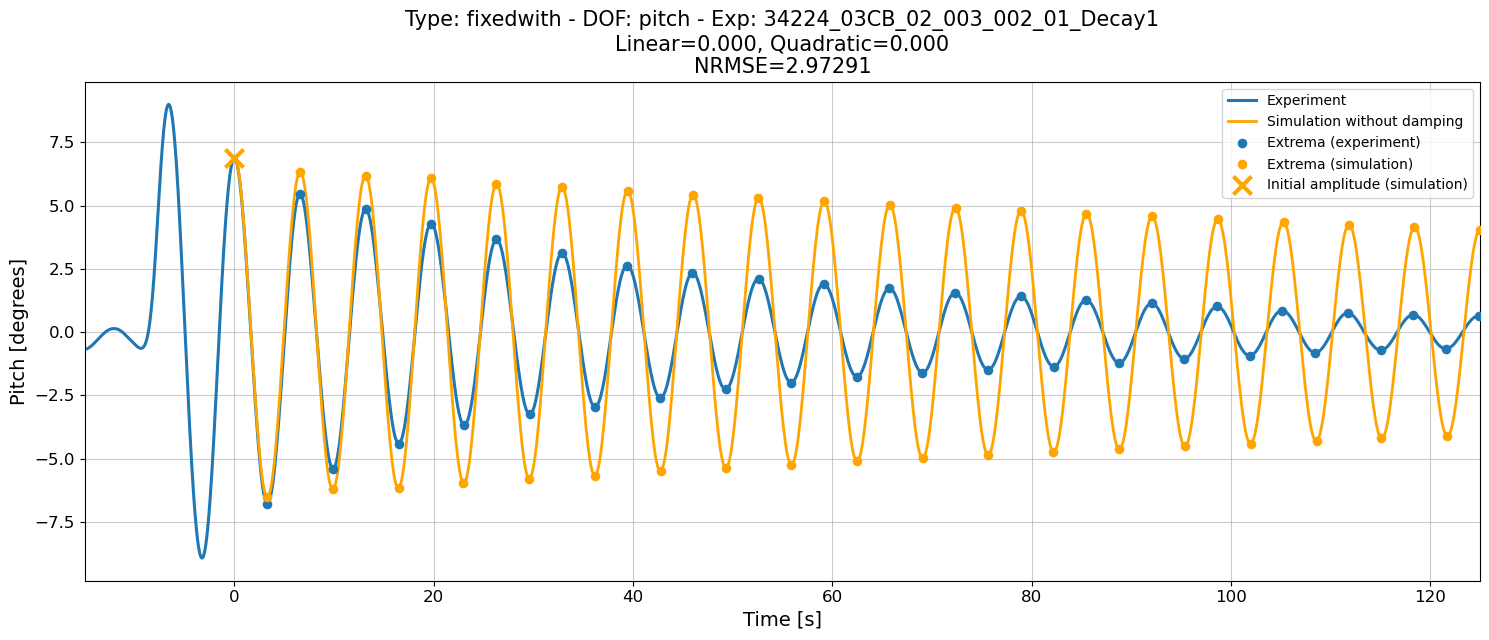

,case_id,case_label,construction,construction_label,dof,exp_path,model_path,linear_damping,quadratic_damping,keep_heave_damping_active,active_heave_linear_damping,active_heave_quadratic_damping,nrmse_total,nrmse_peaks,nrmse_troughs,n_matched_peaks,n_matched_troughs,plot_path
0,fitted_damping,Best simulation,fixedwith,Fixed with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,303.333,50.0,True,4.4375,2.9375,0.084354,0.079249,0.089460,20,21,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...
1,without_damping,Simulation without damping,fixedwith,Fixed with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,0.000,0.0,True,4.4375,2.9375,2.972913,2.941485,3.004342,20,21,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...


Saved plots:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_pitch_fixedwith_damped_vs_undamped\pitch_fixedwith_best_simulation.png
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_pitch_fixedwith_damped_vs_undamped\pitch_fixedwith_without_damping.png
Saved summary Excel: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\pitch_fixedwith_damped_vs_undamped_summary.xlsx


In [12]:
# ============================================================
# 8. Save plots and summary table
# ============================================================
plot_paths = []
for result in results:
    out_path = plot_case(result, plots_dir)
    result["plot_path"] = str(out_path)
    plot_paths.append(out_path)

summary_rows = []
for result in results:
    summary_rows.append({
        "case_id": result["case_id"],
        "case_label": result["title_label"],
        "construction": construction,
        "construction_label": construction_label,
        "dof": dof,
        "exp_path": str(exp_path),
        "model_path": str(model_path),
        "linear_damping": result["linear_damping"],
        "quadratic_damping": result["quadratic_damping"],
        "keep_heave_damping_active": KEEP_HEAVE_DAMPING_ACTIVE,
        "active_heave_linear_damping": selected_heave_damping[construction]["linear"] if KEEP_HEAVE_DAMPING_ACTIVE else 0.0,
        "active_heave_quadratic_damping": selected_heave_damping[construction]["quadratic"] if KEEP_HEAVE_DAMPING_ACTIVE else 0.0,
        "nrmse_total": result["nrmse_total"],
        "nrmse_peaks": result["nrmse_peaks"],
        "nrmse_troughs": result["nrmse_troughs"],
        "n_matched_peaks": result["n_matched_peaks"],
        "n_matched_troughs": result["n_matched_troughs"],
        "plot_path": result["plot_path"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

with pd.ExcelWriter(output_excel_path, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)

print("Saved plots:")
for path in plot_paths:
    print(path)
print(f"Saved summary Excel: {output_excel_path}")